# 13 - print results of mean err for all partitions

In [2]:
from nested_pandas.utils import count_nested
import numpy as np
import pandas as pd
import nested_pandas as npd

import dask
import numpy.ma as ma
import math
from hats import HealpixPixel
from homework_plotting import per_detector

# lsdb.show_versions()

In [3]:
all_results = npd.read_parquet("full_results/part0.parquet")
# all_results

In [4]:
sum_summary = {}
sum_square_summary = {}
count_summary = {}
means = {}
std_devs = {}

for band in "ugrizy":
    sums = np.vstack(all_results[f"diffs_{band}.sums"].to_numpy()).sum(axis=0)
    sum_summary[band] = sums
    sum_squares = np.vstack(all_results[f"diffs_{band}.sum_squares"].to_numpy()).sum(axis=0)
    sum_square_summary[band] = sum_squares

    counts = np.vstack(all_results[f"diffs_{band}.counts"].to_numpy()).sum(axis=0)
    count_summary[band] = counts
    counts = ma.masked_where(counts == 0, counts)
    means[band] = sums / counts
    std_devs[band] = (sum_squares / counts) - (sums / counts) ** 2


## Detections by band, binned in detector

/home/d/delucchi/git/linccf/internal/mar26_homework/homework_plotting.py:23: UserWarning: Warning: converting a masked element to nan.
  rec_array[detector_simplified_xy["x"][detector_number]][detector_simplified_xy["y"][detector_number]] = bin_value
/home/d/delucchi/git/linccf/internal/mar26_homework/homework_plotting.py:23: UserWarning: Warning: converting a masked element to nan.
  rec_array[detector_simplified_xy["x"][detector_number]][detector_simplified_xy["y"][detector_number]] = bin_value


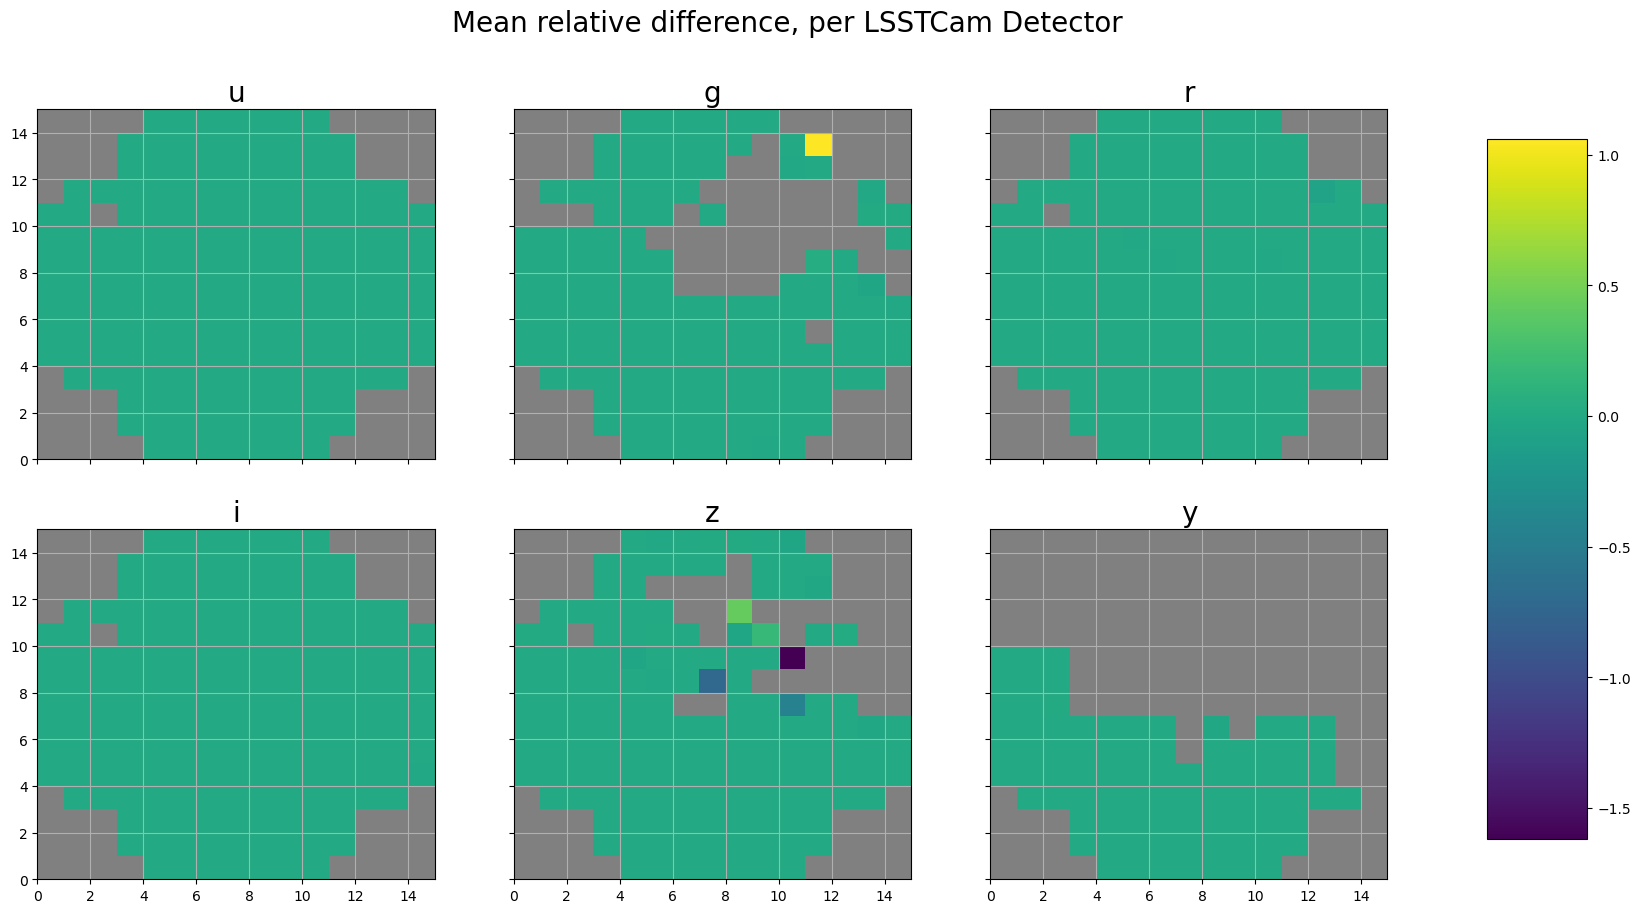

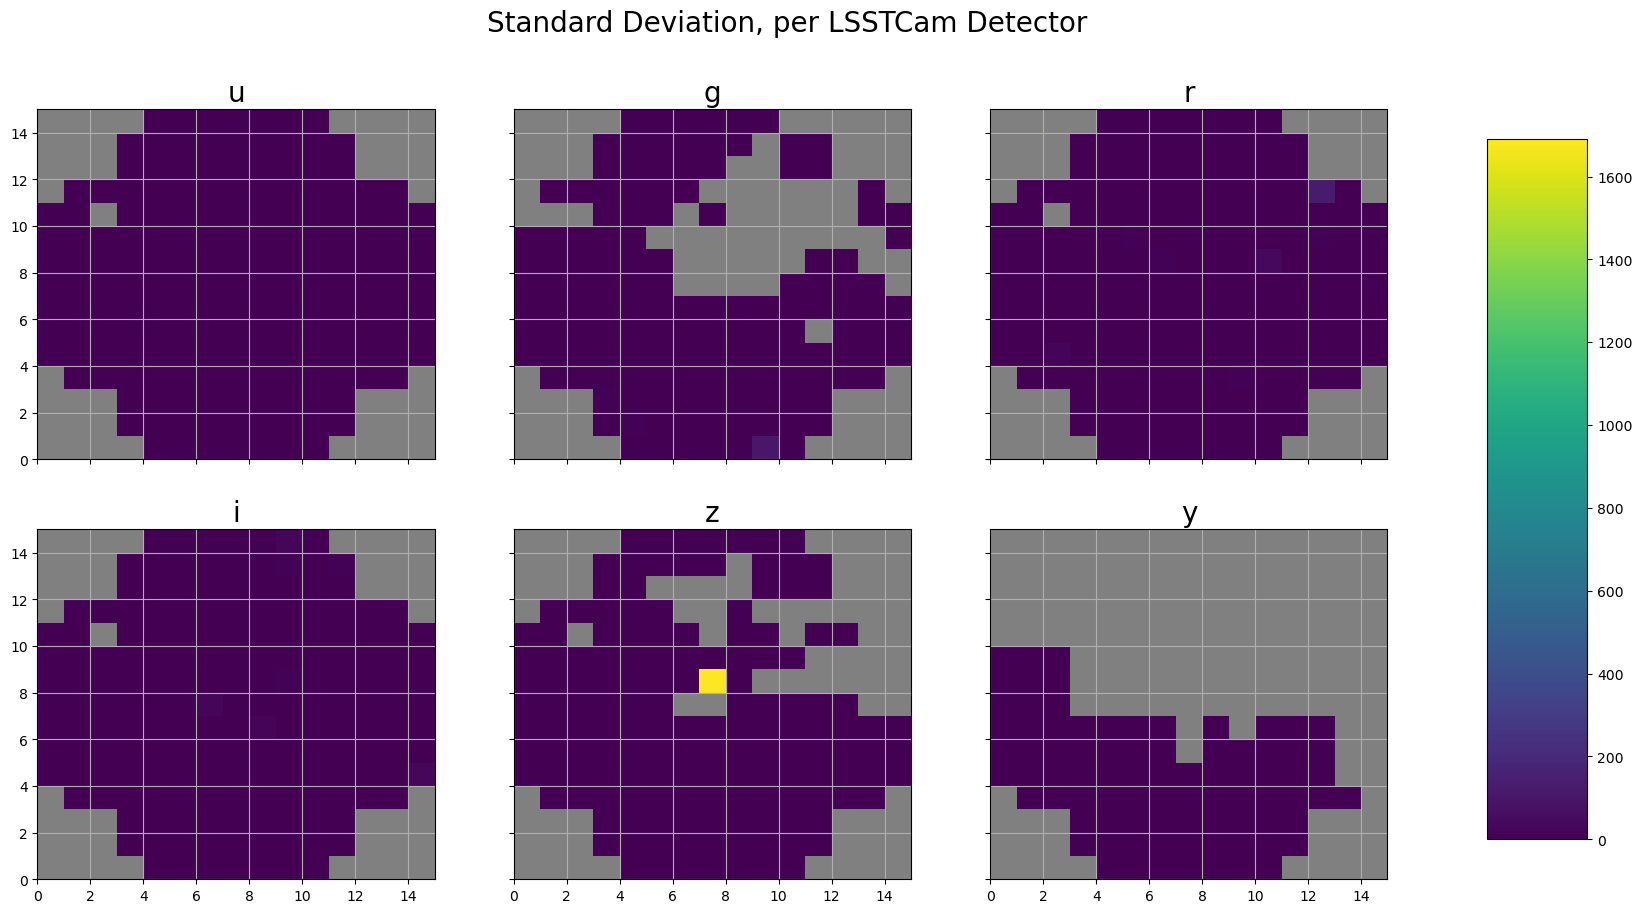

In [5]:
per_detector(means, "Mean relative difference, per LSSTCam Detector")
per_detector(std_devs, "Standard Deviation, per LSSTCam Detector")